In [ ]:
import os, re, json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from IPython.display import display
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/project/data/raw/Images.zip" -d "/content/Images"

replace /content/Images/1000268201_693b08cb0e.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
CAPTION_FILE = "/content/drive/MyDrive/project/data/raw/captions.txt"
IMG_DIR      = "/content/Images"
VOCAB_PATH   = "/content/drive/MyDrive/project/data/vocab/vocab.json"  # vocab đã build sẵn
MIN_FREQ     = 5
MAX_SEQ_LEN  = 50

In [ ]:
# ── Palette & rcParams ──────────────────────────────────────────────
C = dict(blue="#2563EB", green="#10B981", amber="#F59E0B",
         red="#EF4444",  slate="#64748B", bg="#F8FAFC",
         purple="#7C3AED", pink="#EC4899")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": C["bg"],
    "axes.grid": True,  "grid.alpha": 0.35,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# **Tổng quan Dataset**

  Tổng số ảnh       : 8,091
  Tổng số captions  : 40,455
  Caption / ảnh     : 5

Ví dụ — ảnh '1000268201_693b08cb0e.jpg':


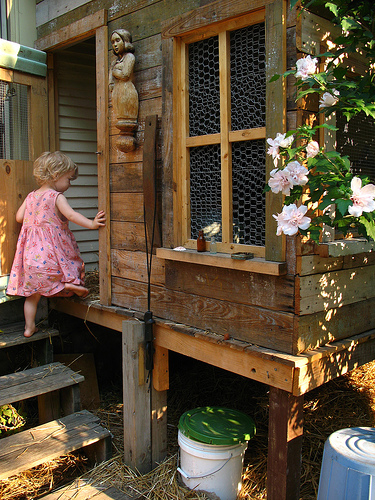


  • A child in a pink dress is climbing up a set of stairs in an entry way .
  • A girl going into a wooden building .
  • A little girl climbing into a wooden playhouse .
  • A little girl climbing the stairs to her playhouse .
  • A little girl in a pink dress going into a wooden cabin .


In [ ]:
def load_captions(path):
    df = pd.read_csv(path)
    if {"image", "caption"}.issubset(df.columns):
        captions = {}
        for img, cap in zip(df["image"], df["caption"]):
            captions.setdefault(str(img).strip(), []).append(str(cap).strip())
        return captions
    raise ValueError("CSV cần có cột 'image' và 'caption'")

captions   = load_captions(CAPTION_FILE)
all_images = list(captions.keys())
all_caps   = [c for caps in captions.values() for c in caps]

print("="*50)
print(f"  Tổng số ảnh       : {len(all_images):,}")
print(f"  Tổng số captions  : {len(all_caps):,}")
print(f"  Caption / ảnh     : {len(all_caps) // len(all_images)}")
print("="*50)

print(f"\nVí dụ — ảnh '{all_images[0]}':"  )
img = Image.open(os.path.join(IMG_DIR, all_images[0]))
display(img)
print()
for c in captions[all_images[0]]:
    print(f"  • {c}")

# **Phân tích Captions**

### **Thống kê độ dài & Vocab**

In [ ]:
def tokenize(text):
    """Lowercase + strip punctuation — khớp với Vocabulary._tokenize()"""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

lengths     = np.array([len(tokenize(c)) for c in all_caps])
all_tokens  = [tok for c in all_caps for tok in tokenize(c)]
raw_counter = Counter(all_tokens)

# Vocab với min_freq filter
filtered   = {w for w, cnt in raw_counter.items() if cnt >= MIN_FREQ}
vocab_size = len(filtered) + 2          # +2: <pad>, <unk>
within     = (lengths <= MAX_SEQ_LEN).sum()

stats = {
    "min"    : int(lengths.min()),
    "max"    : int(lengths.max()),
    "mean"   : round(float(lengths.mean()), 2),
    "median" : float(np.median(lengths)),
    "std"    : round(float(lengths.std()), 2),
    "p90"    : int(np.percentile(lengths, 90)),
    "p95"    : int(np.percentile(lengths, 95)),
    "p99"    : int(np.percentile(lengths, 99)),
}

print("Thống kê độ dài caption (số từ sau tokenize):")
for k, v in stats.items():
    print(f"  {k:8s}: {v}")
print()
print(f"  Vocab raw (chưa lọc)         : {len(raw_counter):,} từ")
print(f"  Từ bị lọc (freq < {MIN_FREQ})         : {len(raw_counter)-len(filtered):,}")
print(f"  Vocab cuối (min_freq={MIN_FREQ}) + 2  : {vocab_size:,} từ")
print()
print(f"  max_seq_len={MAX_SEQ_LEN}: bao phủ {within/len(lengths)*100:.1f}% captions")

Thống kê độ dài caption (số từ sau tokenize):
  min     : 1
  max     : 37
  mean    : 10.82
  median  : 10.0
  std     : 3.77
  p90     : 16
  p95     : 18
  p99     : 22

  Vocab raw (chưa lọc)         : 8,488 từ
  Từ bị lọc (freq < 5)         : 5,510
  Vocab cuối (min_freq=5) + 2  : 2,980 từ

  max_seq_len=50: bao phủ 100.0% captions


### **Phân phối độ dài Caption**

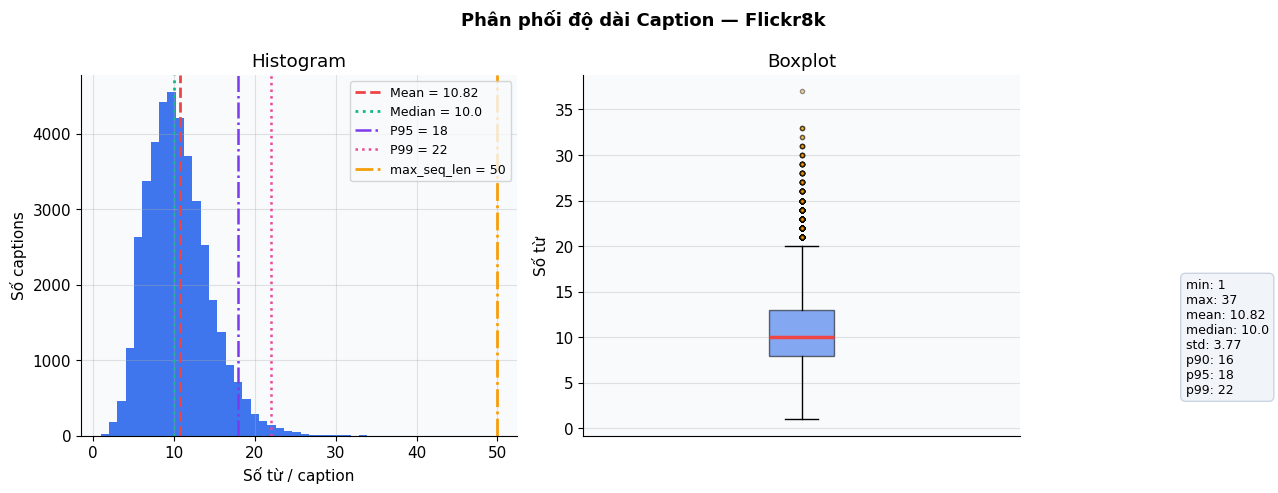

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5)) # Changed from 1,3 to 1,2
fig.suptitle("Phân phối độ dài Caption — Flickr8k", fontweight="bold", fontsize=13)

# ── Histogram ──────────────────────────────────────────────────────
ax = axes[0]
ax.hist(lengths, bins=35, color=C["blue"], ec="white", lw=0.5, alpha=0.88)
ax.axvline(stats["mean"],    color=C["red"],    ls="--", lw=2, label=f'Mean = {stats["mean"]}')
ax.axvline(stats["median"],  color=C["green"],  ls=":",  lw=2, label=f'Median = {stats["median"]}')
ax.axvline(stats["p95"],     color=C["purple"], ls="-.", lw=1.8, label=f'P95 = {stats["p95"]}')
ax.axvline(stats["p99"],     color=C["pink"],   ls=":",  lw=1.8, label=f'P99 = {stats["p99"]}')
ax.axvline(MAX_SEQ_LEN,      color=C["amber"],  ls="-.", lw=2, label=f'max_seq_len = {MAX_SEQ_LEN}')
ax.set_xlabel("Số từ / caption"); ax.set_ylabel("Số captions")
ax.set_title("Histogram"); ax.legend(fontsize=9)

# ── Boxplot ────────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor=C["blue"], alpha=0.55),
                medianprops=dict(color=C["red"], lw=2.5),
                flierprops=dict(marker="o", ms=3, alpha=0.4, markerfacecolor=C["amber"]))
ax.set_ylabel("Số từ"); ax.set_title("Boxplot"); ax.set_xticks([])
info = "\n".join(f"{k}: {v}" for k, v in stats.items())
ax.text(1.38, np.median(lengths), info,
        transform=ax.get_yaxis_transform(), fontsize=9, va="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="#F1F5F9", ec="#CBD5E1"))

plt.tight_layout();
plt.show()

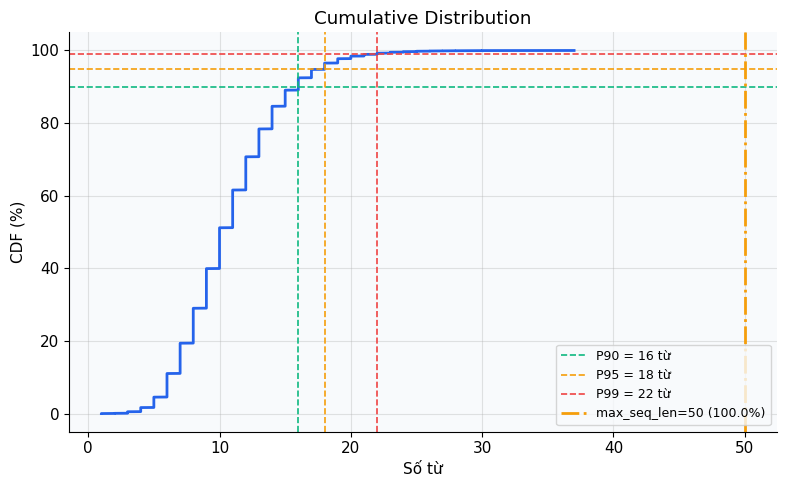

In [ ]:
# ── Cumulative distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sorted_len = np.sort(lengths)
cdf        = np.arange(1, len(sorted_len)+1) / len(sorted_len) * 100
ax.plot(sorted_len, cdf, color=C["blue"], lw=2)
for pct, col in [(90, C["green"]), (95, C["amber"]), (99, C["red"])]:
    idx = int(np.searchsorted(cdf, pct))
    val = sorted_len[min(idx, len(sorted_len)-1)]
    ax.axhline(pct, color=col, ls="--", lw=1.2)
    ax.axvline(val, color=col, ls="--", lw=1.2, label=f"P{pct} = {val} từ")
ax.axvline(MAX_SEQ_LEN, color=C["amber"], ls="-.", lw=2,
           label=f"max_seq_len={MAX_SEQ_LEN} ({within/len(lengths)*100:.1f}%)")
ax.set_xlabel("Số từ"); ax.set_ylabel("CDF (%)")
ax.set_title("Cumulative Distribution"); ax.legend(fontsize=9)

plt.tight_layout();
plt.show()

### **Phân tích từ vựng**

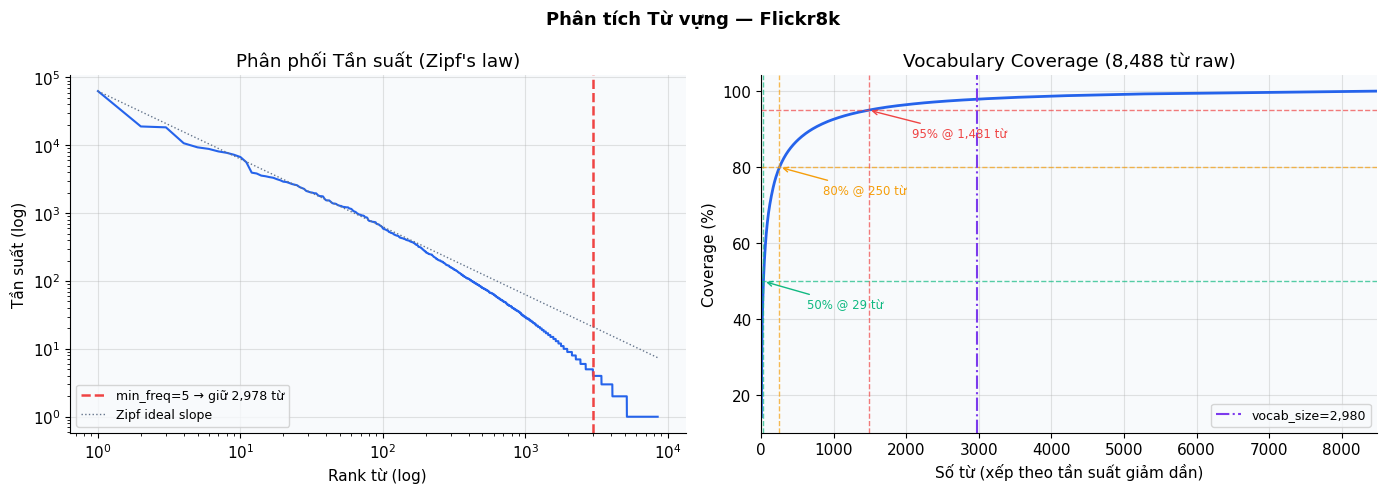

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phân tích Từ vựng — Flickr8k", fontweight="bold", fontsize=13)

# ── Zipf log-log ───────────────────────────────────────────────────
ax = axes[0]
freq_vals = np.array(sorted(raw_counter.values(), reverse=True))
ax.loglog(range(1, len(freq_vals)+1), freq_vals, color=C["blue"], lw=1.5)
ax.axvline(len(filtered), color=C["red"], ls="--", lw=1.8,
           label=f"min_freq={MIN_FREQ} → giữ {len(filtered):,} từ")
# Reference Zipf slope
x_ref = np.array([1, len(freq_vals)])
ax.loglog(x_ref, freq_vals[0] / x_ref, color=C["slate"], ls=":", lw=1, label="Zipf ideal slope")
ax.set_xlabel("Rank từ (log)"); ax.set_ylabel("Tần suất (log)")
ax.set_title("Phân phối Tần suất (Zipf's law)"); ax.legend(fontsize=9)

# ── Coverage curve ─────────────────────────────────────────────────
ax = axes[1]
sorted_freq = sorted(raw_counter.values(), reverse=True)
cumsum = np.cumsum(sorted_freq) / sum(sorted_freq) * 100
ax.plot(range(1, len(cumsum)+1), cumsum, color=C["blue"], lw=2)
for pct, col in [(50, C["green"]), (80, C["amber"]), (95, C["red"])]:
    idx = int(np.searchsorted(cumsum, pct))
    ax.axhline(pct, color=col, ls="--", lw=1, alpha=0.7)
    ax.axvline(idx, color=col, ls="--", lw=1, alpha=0.7)
    ax.annotate(f"{pct}% @ {idx:,} từ", xy=(idx, pct),
                xytext=(idx + len(cumsum)*0.07, pct - 7),
                fontsize=8.5, color=col,
                arrowprops=dict(arrowstyle="->", color=col, lw=1))
ax.axvline(vocab_size, color=C["purple"], ls="-.", lw=1.5,
           label=f"vocab_size={vocab_size:,}")
ax.set_xlabel("Số từ (xếp theo tần suất giảm dần)"); ax.set_ylabel("Coverage (%)")
ax.set_xlim(0, min(len(cumsum), 10000))
ax.set_title(f"Vocabulary Coverage ({len(raw_counter):,} từ raw)"); ax.legend(fontsize=9)

plt.tight_layout();
plt.show()

### **Top-30 từ phổ biến nhất**

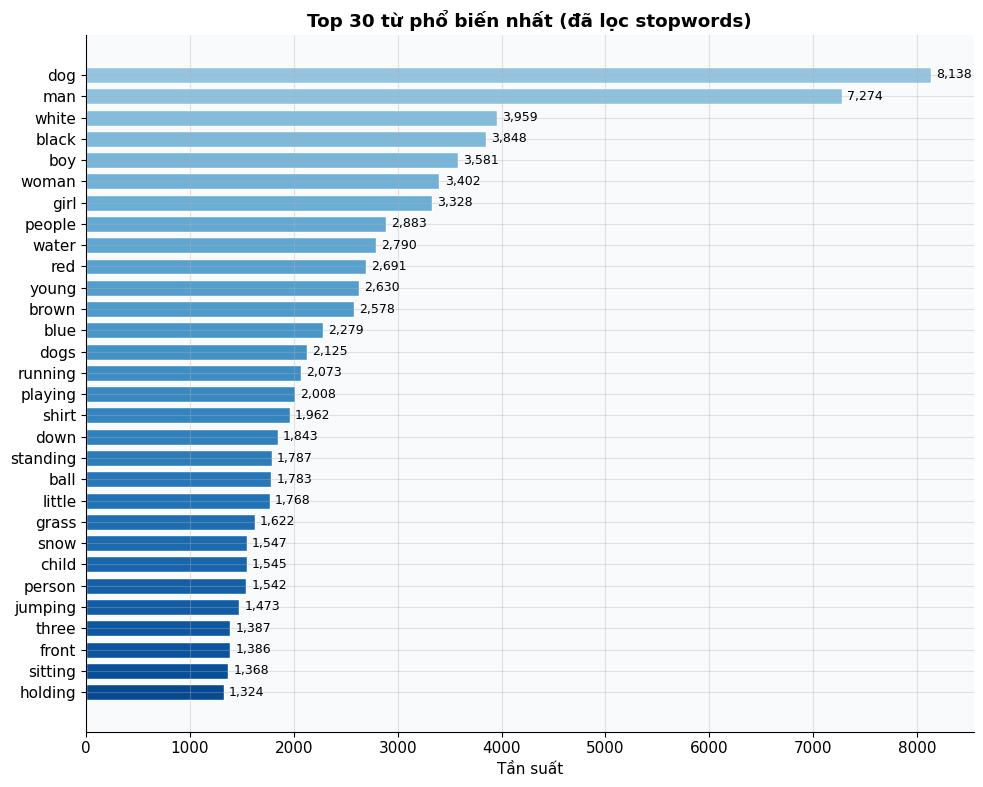

In [ ]:
STOPWORDS = {"a","an","the","is","in","on","and","of","with",
             "at","to","are","his","her","its","their","two",
             "one","into","by","as","from","while","for","through",
             "wearing","that","has","have","been","not","over"}

top30 = [(w, cnt) for w, cnt in raw_counter.most_common(300)
         if w not in STOPWORDS][:30]

words_plot = [w for w, _ in top30]
freqs_plot = [c for _, c in top30]

fig, ax = plt.subplots(figsize=(10, 8))
# Color gradient by frequency
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top30)))[::-1]
bars = ax.barh(words_plot[::-1], freqs_plot[::-1], color=colors, ec="white", height=0.75)
for bar, freq in zip(bars, freqs_plot[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{freq:,}", va="center", fontsize=9)
ax.set_xlabel("Tần suất")
ax.set_title("Top 30 từ phổ biến nhất (đã lọc stopwords)", fontweight="bold")
plt.tight_layout();
plt.show()

# **Karpathy Split**

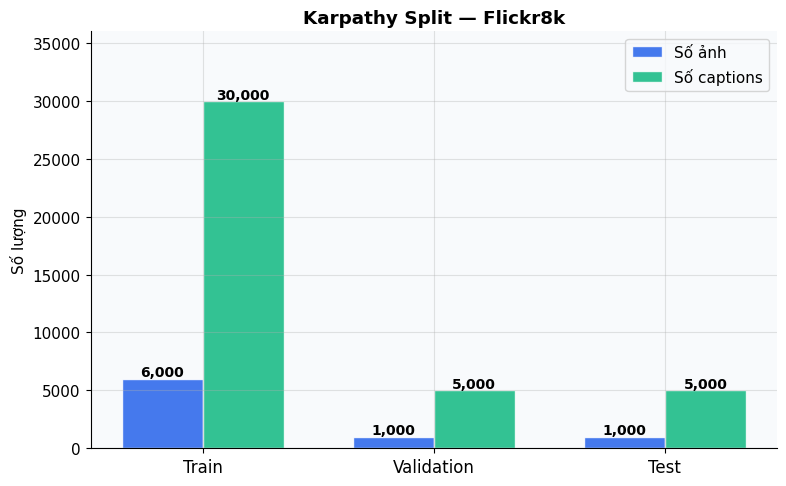

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
w = 0.35

b1 = ax.bar(x - w/2, [6000, 1000, 1000], w,
            label="Số ảnh",     color=C["blue"],  alpha=0.85, ec="white")
b2 = ax.bar(x + w/2, [30000, 5000, 5000], w,
            label="Số captions", color=C["green"], alpha=0.85, ec="white")

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f"{bar.get_height():,}",
            ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Train", "Validation", "Test"], fontsize=12)
ax.set_ylabel("Số lượng")
ax.set_title("Karpathy Split — Flickr8k", fontweight="bold")
ax.legend()
ax.set_ylim(0, 36000)

plt.tight_layout()
plt.show()

# **Ảnh**

### **Kích thước ảnh**

Đọc kích thước ảnh:   0%|          | 0/500 [00:00<?, ?it/s]

Đọc 500 ảnh
Width  — mean: 458, min: 182, max: 500
Height — mean: 394, min: 176, max: 500


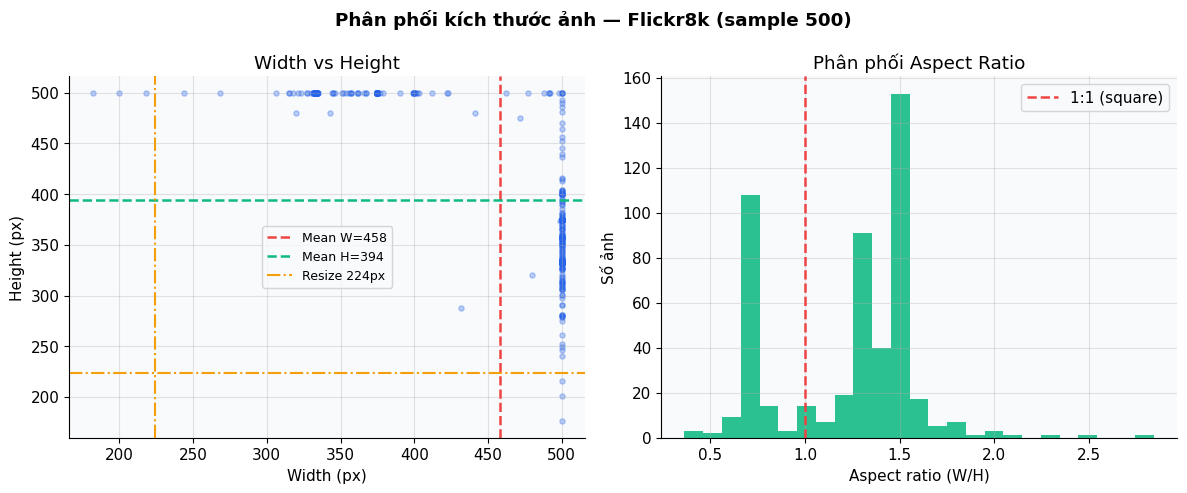

In [ ]:
widths, heights = [], []
img_dir = Path(IMG_DIR)

if img_dir.exists():
    img_files = list(img_dir.glob("*.jpg"))[:500]
    for p in tqdm(img_files, desc="Đọc kích thước ảnh"):
        try:
            w, h = Image.open(p).size
            widths.append(w); heights.append(h)
        except: pass

    print(f"Đọc {len(widths)} ảnh")
    print(f"Width  — mean: {np.mean(widths):.0f}, min: {min(widths)}, max: {max(widths)}")
    print(f"Height — mean: {np.mean(heights):.0f}, min: {min(heights)}, max: {max(heights)}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Phân phối kích thước ảnh — Flickr8k (sample 500)",
                 fontweight="bold")

    ax = axes[0]
    ax.scatter(widths, heights, alpha=0.3, s=14, color=C["blue"])
    ax.axvline(np.mean(widths),  color=C["red"],   ls="--", lw=1.8,
               label=f"Mean W={np.mean(widths):.0f}")
    ax.axhline(np.mean(heights), color=C["green"], ls="--", lw=1.8,
               label=f"Mean H={np.mean(heights):.0f}")
    ax.axvline(224, color=C["amber"], ls="-.", lw=1.5, label="Resize 224px")
    ax.axhline(224, color=C["amber"], ls="-.", lw=1.5)
    ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")
    ax.set_title("Width vs Height"); ax.legend(fontsize=9)

    ax = axes[1]
    ratios = [ww/hh for ww, hh in zip(widths, heights)]
    ax.hist(ratios, bins=25, color=C["green"], ec="white", alpha=0.88)
    ax.axvline(1.0, color=C["red"], ls="--", lw=1.8, label="1:1 (square)")
    ax.set_xlabel("Aspect ratio (W/H)"); ax.set_ylabel("Số ảnh")
    ax.set_title("Phân phối Aspect Ratio"); ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"  Không tìm thấy '{IMG_DIR}' — bỏ qua.")

### **Sample Grid**

In [ ]:
if img_dir.exists():
    import random
    random.seed(42)
    sample_paths = random.sample(img_files, min(20, len(img_files)))

    fig, axes = plt.subplots(4, 5, figsize=(16, 13))
    fig.suptitle("Sample Grid — 20 ảnh ngẫu nhiên từ Flickr8k",
                 fontweight="bold", fontsize=13, y=1.01)

    for ax, p in zip(axes.flat, sample_paths):
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        # Hiển thị caption đầu tiên (cắt ngắn)
        fname = p.name
        cap   = captions.get(fname, [""])[0]
        cap_short = cap[:55] + "..." if len(cap) > 55 else cap
        ax.set_title(cap_short, fontsize=7, wrap=True)
        ax.axis("off")

    plt.tight_layout(); plt.savefig("sample_grid.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("  Không tìm thấy thư mục ảnh — bỏ qua sample grid.")

Output hidden; open in https://colab.research.google.com to view.

# **Tổng hợp**

In [ ]:
summary_rows = [
    ("Dataset", "", ""),
    ("  Tổng số ảnh",                               len(all_images),         ""),
    ("  Tổng số captions",                          len(all_caps),           ""),
    ("  Caption / ảnh",                             len(all_caps)//len(all_images), ""),

    ("Độ dài Caption", "", ""),
    ("  min / max (từ)",                            f"{stats['min']} / {stats['max']}", ""),
    ("  mean ± std",                                f"{stats['mean']} ± {stats['std']}", ""),
    ("  median",                                    stats["median"],         ""),
    ("  P90 / P95 / P99",                          f"{stats['p90']} / {stats['p95']} / {stats['p99']}", ""),
    (f"  Caption ≤ max_seq_len={MAX_SEQ_LEN} (%)",    f"{within/len(lengths)*100:.1f}%", ""),

    ("Từ vựng", "", ""),
    ("  Raw vocab (chưa lọc)",                      f"{len(raw_counter):,}", ""),
    ("  Filtered vocab (min_freq=5) + specials",    f"{vocab_size:,}",       ""),
    ("  Độ bao phủ 50% corpus",                   "~top-N từ",            "xem biểu đồ coverage"),

    ("Ảnh (mẫu 500)", "", ""),
]
if widths:
    summary_rows += [
        ("  Width mean / Height mean",
         f"{np.mean(widths):.0f}px / {np.mean(heights):.0f}px", ""),
        ("  Tỷ lệ khung hình trung bình",
         f"{np.mean(ratios):.2f}", "chủ yếu là ảnh ngang"),
        ("  Đầu vào ResNet",
         "224×224 (resize + center-crop)", "phù hợp với sự đa dạng kích thước"),
    ]

df_sum = pd.DataFrame(
    [(r[0], r[1], r[2]) for r in summary_rows],
    columns=["Chỉ số", "Giá trị", "Ghi chú"]
)

try:
    # Sử dụng style với hiển thị header rõ ràng
    styled_df = df_sum.style.hide(axis='index')\
                            .set_properties(**{'text-align': 'left'})\
                            .set_table_styles([
                                {'selector': 'th', 'props': [('text-align', 'left'),
                                                             ('background-color', '#E2E8F0'),
                                                             ('color', '#1E293B'),
                                                             ('font-weight', 'bold')]}
                            ])
    display(styled_df)
except Exception:
    print(df_sum.to_string(index=False))

Chỉ số,Giá trị,Ghi chú
Dataset,,
Tổng số ảnh,8091,
Tổng số captions,40455,
Caption / ảnh,5,
Độ dài Caption,,
min / max (từ),1 / 37,
mean ± std,10.82 ± 3.77,
median,10.000000,
P90 / P95 / P99,16 / 18 / 22,
Caption ≤ max_seq_len=50 (%),100.0%,


# **Nhận xét và đề xuất thiết kế mô hình**

### **Tối ưu hóa Chuỗi (Sequence Length)**
| Quan sát | Hàm ý cho thiết kế |
| :--- | :--- |
| **P99 = 22 từ, Max = 37 từ** | `MAX_SEQ_LEN = 50` bao phủ **100.0%** dữ liệu. Việc chọn 50 (thay vì 64 hay 128) giúp tiết kiệm đáng kể VRAM mà không làm mất thông tin. |
| **Phân phối lệch phải nhẹ** | Cấu trúc câu tập trung dày ở mức 10-15 từ giúp cơ chế *Teacher-forcing* hoạt động ổn định, không cần áp dụng *curriculum learning* quá phức tạp. |

### **Chiến lược Từ vựng (Vocabulary)**
| Quan sát | Hàm ý cho thiết kế |
| :--- | :--- |
| **Filtered Vocab ≈ 3,000 từ** | Với quy mô này, `EMBED_DIM = 512` là lựa chọn mạnh mẽ. Tránh dùng dim quá lớn (>1024) để ngăn chặn overfitting trên tập corpus nhỏ. |
| **Quy luật Zipf rõ rệt** | Việc lọc `min_freq=5` loại bỏ phần lớn từ hiếm nhưng chỉ mất <5% số lần xuất hiện thực tế (token occurrences). |
| **Coverage 95%** | Chỉ cần ~3,000 từ + token `<unk>` là đủ bao phủ ngữ nghĩa, do đó không cần thiết phải dùng các bộ tách từ phức tạp như BPE hay WordPiece. |

### **Trích xuất đặc trưng Hình ảnh (Visual Encoder)**
| Quan sát | Hàm ý cho thiết kế |
| :--- | :--- |
| **8,091 ảnh đa dạng (W/H ratio)** | Cần **Resize + Center-Crop về 224x224** và chuẩn hóa theo ImageNet stats: Mean `[0.485, 0.456, 0.406]`, Std `[0.229, 0.224, 0.225]`. |
| **Visual Corpus nhỏ** | Sử dụng **Pre-trained ResNet-50** là bắt buộc. Nếu train từ đầu (scratch) chắc chắn sẽ bị *underfit*. |
| **Fine-tuning theo lớp** | Đóng băng các tầng đầu, chỉ nên giã đông từ `layer4` trở đi kết hợp với tầng FC để mô hình thích nghi tốt nhất với đặc trưng của Flickr8k. |
| **1 ảnh kèm 5 captions** | Tăng cường dữ liệu (*Data Augmentation*) như lật ngang, jitter màu sắc sẽ nhân 5 lần hiệu quả chống "học vẹt" cho Encoder. |